<a href="https://colab.research.google.com/github/Abhi0129n/Machine-learning-/blob/main/crop%20yield%20predicting%20using%20robust%20regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Huber Training:
(1.727436242685795, 11.92946976194749, np.float64(3.4539064495072083), 0.4613060594509326)

Huber Testing:
(2.2974007874530535, 23.112888021703352, np.float64(4.807586506939147), 0.18801322151172728)

OLS Training:
(1.8884961596938388, 11.233885305831917, np.float64(3.3516988686085623), 0.4927162678782019)

OLS Testing:
(2.7324582575932763, 26.16627929324274, np.float64(5.11529855367629), 0.08074348785865171)

Sample Predictions:
      Actual  Huber Predicted  OLS Predicted
0  13.300955        14.050144      13.276661
1  12.835623        11.045467      10.263851
2  11.776823        12.368135      12.324900
3  13.829703        15.436531      16.280859
4  16.844880        17.602217      19.465233
5   9.323441        12.439762      13.552467
6  30.759514        12.088052      11.953714
7  14.534063        14.139587      14.416538
8  10.809105        10.538699      10.358207
9  14.716041        13.852325      14.629592


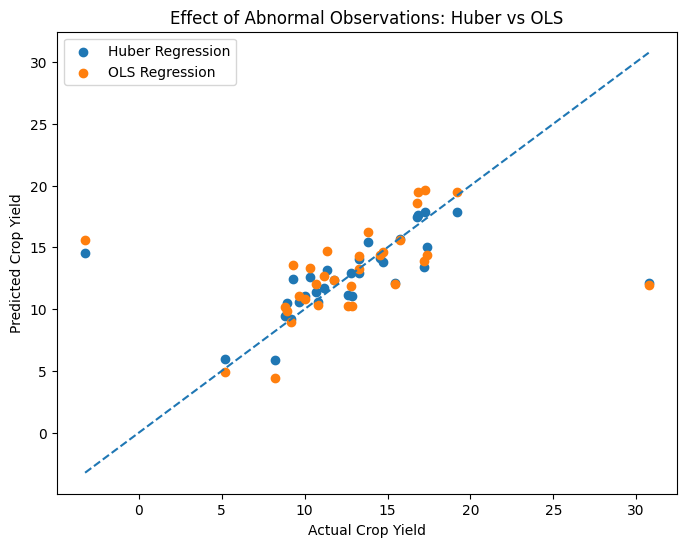

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)

# Generate 160 observations
n = 160

soil_moisture = np.random.uniform(20, 80, n)
soil_temperature = np.random.uniform(15, 35, n)
nitrogen = np.random.uniform(20, 120, n)
phosphorus = np.random.uniform(10, 80, n)
potassium = np.random.uniform(20, 100, n)
sunlight = np.random.uniform(4, 12, n)

# Generate crop yield
crop_yield = (
    0.08 * soil_moisture
    - 0.12 * soil_temperature
    + 0.05 * nitrogen
    + 0.03 * phosphorus
    + 0.04 * potassium
    + 0.6 * sunlight
    + np.random.normal(0, 1.5, n)
)

# Introduce abnormal observations
outlier_idx = np.random.choice(
    n, 8, replace=False
)

crop_yield[outlier_idx] += np.random.choice(
    [-15, 15], size=8
)

# Create dataset
X = pd.DataFrame({
    "Soil_Moisture": soil_moisture,
    "Soil_Temperature": soil_temperature,
    "Nitrogen": nitrogen,
    "Phosphorus": phosphorus,
    "Potassium": potassium,
    "Sunlight": sunlight
})

y = crop_yield

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Robust Regression
huber = HuberRegressor(max_iter=1000)
huber.fit(X_train_scaled, y_train)

# OLS Regression
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Predictions
huber_train_pred = huber.predict(X_train_scaled)
huber_test_pred = huber.predict(X_test_scaled)

ols_train_pred = ols.predict(X_train_scaled)
ols_test_pred = ols.predict(X_test_scaled)

# Evaluation function
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

# Huber performance
huber_train = evaluate(
    y_train, huber_train_pred
)

huber_test = evaluate(
    y_test, huber_test_pred
)

# OLS performance
ols_train = evaluate(
    y_train, ols_train_pred
)

ols_test = evaluate(
    y_test, ols_test_pred
)

print("Huber Training:")
print(huber_train)

print("\nHuber Testing:")
print(huber_test)

print("\nOLS Training:")
print(ols_train)

print("\nOLS Testing:")
print(ols_test)

# Display sample predictions
results = pd.DataFrame({
    "Actual": y_test,
    "Huber Predicted": huber_test_pred,
    "OLS Predicted": ols_test_pred
})

print("\nSample Predictions:")
print(results.head(10))

# Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    huber_test_pred,
    label="Huber Regression"
)

plt.scatter(
    y_test,
    ols_test_pred,
    label="OLS Regression"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--"
)

plt.xlabel("Actual Crop Yield")
plt.ylabel("Predicted Crop Yield")

plt.title(
    "Effect of Abnormal Observations: Huber vs OLS"
)

plt.legend()
plt.show()